In [1]:
# installing all required packages
!pip install transformers datasets torch scikit-learn pandas matplotlib seaborn accelerate

In [2]:
# importing everything needed for the assignment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    pipeline,
    get_scheduler
)

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)
from sklearn.preprocessing import LabelEncoder

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

PyTorch version: 2.10.0+cu128
GPU available: True
Using device: cuda


In [3]:
# loading the customer support tickets dataset from huggingface
dataset = load_dataset("Tobi-Bueck/customer-support-tickets")
print(dataset)

README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8'],
        num_rows: 61765
    })
})


In [4]:
# converting to pandas for easier exploration
df = pd.DataFrame(dataset['train'])
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head(10)

Shape: (61765, 16)

Columns: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None
5,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,high,en,51.0,Feature,Product,Documentation,Feedback,None,None,None,None
6,System Interruptions,"Dear Customer Support Team,\n\nI am submitting...",Thank you for bringing the system disruptions ...,Incident,Service Outages and Maintenance,high,en,51.0,Outage,Disruption,Performance,IT,Tech Support,None,None,None
7,Connectivity Problems with Printer on MacBook Pro,"Dear Support Team,\n\nI am reporting a recurri...",Thank you for reaching out regarding the conne...,Incident,Technical Support,medium,en,51.0,Network,Hardware,Performance,Bug,Compatibility,None,None,None
8,Anfrage nach detaillierten Angaben zur Systema...,"Sehr geehrtes Kundensupport-Team,\n\nich hoffe...",Vielen Dank für Ihre Anfrage. Wir stellen Ihne...,Request,Technical Support,low,de,51.0,Documentation,Feedback,IT,Tech Support,None,None,None,None
9,Anfrage zur Klärung der Auswirkungen eines Ser...,"Sehr geehrtes Kundendienstteam,\n\nich hoffe, ...","Vielen Dank, dass Sie uns bezüglich des kürzli...",Request,Service Outages and Maintenance,high,de,51.0,Disruption,Outage,Recovery,Support,None,None,None,None


In [5]:
# exploring the dataset - checking for nulls and understanding data
print("Missing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)
print("\nBasic stats:")
print(df.describe(include='all'))

Missing values:
subject      5299
body            2
answer      13189
type        13178
queue           0
priority        0
language        0
version     33178
tag_1       13178
tag_2       13237
tag_3       13409
tag_4       17775
tag_5       34129
tag_6       48540
tag_7       55797
tag_8       59293
dtype: int64

Data types:
subject      object
body         object
answer       object
type         object
queue        object
priority     object
language     object
version     float64
tag_1        object
tag_2        object
tag_3        object
tag_4        object
tag_5        object
tag_6        object
tag_7        object
tag_8        object
dtype: object

Basic stats:
                    subject  \
count                 56466   
unique                46635   
top     Problembeschreibung   
freq                      3   
mean                    NaN   
std                     NaN   
min                     NaN   
25%                     NaN   
50%                     NaN   
75%         

In [6]:
# checking what the label/category column looks like
# the dataset may have different column names so identifying the text and label columns
print("Sample rows:")
for col in df.columns:
    print(f"\n--- {col} ---")
    print(df[col].head(5).tolist())

Sample rows:

--- subject ---
['Wesentlicher Sicherheitsvorfall', 'Account Disruption', 'Query About Smart Home System Integration Features', 'Inquiry Regarding Invoice Details', 'Question About Marketing Agency Software Compatibility']

--- body ---
['Sehr geehrtes Support-Team,\\n\\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betrifft. Betroffene Geräte umfassen Projektoren, Bildschirme und Speicherlösungen auf Cloud-Plattformen. Der Grund für die Annahme ist, dass der Vorfall eine potenzielle Datenverletzung im Zusammenhang mit einer Cyberattacke darstellt, was ein erhebliches Risiko für sensible Informationen und den laufenden Geschäftsbetrieb unserer Organisation bedeutet.\\n\\nUnsere initialen Untersuchungen haben ungewöhnliche Aktivitäten und Abweichungen bei den Geräten ergeben. Trotz der Umsetzung unserer standardisierten Behebungs- und Eindämmungsmaßnahmen konnte die Bedrohung bislang nicht vollständig eli

In [7]:
# identifying the correct column names from the dataset
# typically 'text'/'ticket'/'description' and 'label'/'category'/'type'
# adjusting these based on what was printed above

text_col = None
label_col = None

# Prioritize specific text/body columns for 'text_col'
for col in df.columns:
    if 'body' in col.lower():
        text_col = col
        break # Use 'body' if available
    elif 'subject' in col.lower() and text_col is None:
        text_col = col # Fallback to 'subject' if 'body' not found

# For label_col, we need granular categories as per the assignment (Billing, Technical, Delivery, Refund, General).
# The 'type' column is too broad. 'tag_1' seems to contain more specific keywords.
label_col = 'tag_1'

# fallback: use first string col as text, second as label if auto-detect fails (unlikely with this dataset)
if text_col is None:
    text_col = df.select_dtypes(include='object').columns[0]

# If after trying 'tag_1', 'label_col' is still None (e.g., if 'tag_1' didn't exist or was problematic),
# then fall back to the original 'type' column or another suitable object column.
# However, given the context, 'tag_1' is the intended choice.
if label_col is None or label_col not in df.columns:
    print("Warning: 'tag_1' not found or suitable, falling back to 'type' for labels.")
    label_col = 'type'

print(f"Text column identified: {text_col}")
print(f"Label column identified: {label_col}")

# creating a clean working dataframe
df_clean = df[[text_col, label_col]].copy()
df_clean.columns = ['text', 'category']
# Drop rows where either 'text' or 'category' is NaN, as these are crucial for training
df_clean = df_clean.dropna(subset=['text', 'category'])
df_clean['text'] = df_clean['text'].astype(str)
df_clean['category'] = df_clean['category'].astype(str)
print(f"\nClean dataset shape: {df_clean.shape}")
df_clean.head()

Text column identified: body
Label column identified: tag_1

Clean dataset shape: (48585, 2)


,text,category
0,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Security
1,"Dear Customer Support Team,\n\nI am writing to...",Account
2,"Dear Customer Support Team,\n\nI hope this mes...",Product
3,"Dear Customer Support Team,\n\nI hope this mes...",Billing
4,"Dear Support Team,\n\nI hope this message reac...",Product


In [8]:
# looking at the class distribution
print("Category distribution:")
print(df_clean['category'].value_counts())
print(f"\nTotal unique categories: {df_clean['category'].nunique()}")

Category distribution:
category
Security                                                                            9156
Bug                                                                                 7665
Feedback                                                                            5409
Technical                                                                           5032
Feature                                                                             4424
                                                                                    ... 
Consultation                                                                           1
Technical,Customer,Bug,Integration,WordPress,Elasticsearch,Disruption,Resolution       1
Technical,Customer,Bug,Product,Outage,Resolution                                       1
Technical,Bug,Crash,Product                                                            1
Technical,Customer,Bug,Software,Outage,Hardware,Resolution                    

In [9]:
# mapping raw categories to the 5 label groups required by the assignment
# Billing, Technical, Delivery, Refund, General
# checking the actual categories first and mapping accordingly

actual_categories = df_clean['category'].unique().tolist()
print("Actual categories in dataset:")
for cat in actual_categories:
    print(f"  - {cat}")

Actual categories in dataset:
  - Security
  - Account
  - Product
  - Billing
  - Feature
  - Outage
  - Network
  - Documentation
  - Disruption
  - Bug
  - Inquiry
  - Marketing
  - Hardware
  - Video
  - Organization
  - Finance
  - Feedback
  - Refund
  - API
  - Compliance
  - Performance
  - Return
  - Bluetooth
  - Support
  - Maintenance
  - Sales
  - Printer
  - Alert
  - IT
  - Synchronization
  - Display
  - Audio
  - Agile
  - Customer Service
  - Communication
  - Order
  - Team Organization
  - Smart Home
  - Delivery
  - Customer
  - Service
  - Outlook
  - Login
  - Investment Strategy
  - HR
  - Connectivity
  - Customer Support
  - Notification
  - Troubleshooting
  - Investment
  - Touchscreen
  - Process Improvement
  - Configuration
  - Crash
  - Data Discrepancy
  - Performance,Bug,Disruption,Security
  - Integration
  - Pricing
  - Payment
  - Strategy
  - Accessibility
  - Data inconsistency
  - Tech Support
  - Project
  - Performance,Disruption,Outage,Monitor

In [10]:
# defining the label mapping - grouping similar categories into the 5 main classes requested by the assignment
# Billing, Technical, Delivery, Refund, General

# Define keywords for each target label to map from the 'category' column (which is now derived from 'tag_1')
# Adjusted keywords based on observed 'tag_1' values for better mapping
keywords_billing = ['billing', 'payment', 'invoice', 'pricing', 'subscription', 'finance']
keywords_technical = ['technical', 'account', 'login', 'password', 'error', 'bug', 'performance', 'network', 'it', 'software', 'system', 'outage', 'security', 'disruption', 'compatibility', 'connectivity', 'issue', 'problem', 'access', 'data']
keywords_delivery = ['delivery', 'shipping', 'order', 'package', 'tracking', 'logistics', 'delayed', 'missing', 'damaged']
keywords_refund = ['refund', 'return', 'cancellation']

def assign_target_label(tag_value):
    tag_value_lower = str(tag_value).lower()

    if any(kw in tag_value_lower for kw in keywords_billing):
        return 'Billing'
    if any(kw in tag_value_lower for kw in keywords_technical):
        return 'Technical'
    if any(kw in tag_value_lower for kw in keywords_delivery):
        return 'Delivery'
    if any(kw in tag_value_lower for kw in keywords_refund):
        return 'Refund'

    # Catch-all for anything else. This can include Product, Feature, Documentation, General Inquiry etc.
    return 'General'

# Apply the mapping to create the new 'label' column
df_clean['label'] = df_clean['category'].apply(assign_target_label)

print("Label mapping based on keywords from 'tag_1' column values:")
# Display the count of each new label for verification
print(df_clean['label'].value_counts())

Label mapping based on keywords from 'tag_1' column values:
label
Technical    30397
General      15471
Billing       2624
Refund          76
Delivery        17
Name: count, dtype: int64


In [11]:
# encoding labels to integers for the model
label_encoder = LabelEncoder()
df_clean['label_id'] = label_encoder.fit_transform(df_clean['label'])

# creating the id2label and label2id mappings needed for the model config
id2label = {i: label for i, label in enumerate(label_encoder.classes_)}
label2id = {label: i for i, label in id2label.items()}

num_labels = len(id2label)
print(f"Number of classes: {num_labels}")
print(f"Label mapping: {id2label}")

Number of classes: 5
Label mapping: {0: 'Billing', 1: 'Delivery', 2: 'General', 3: 'Refund', 4: 'Technical'}


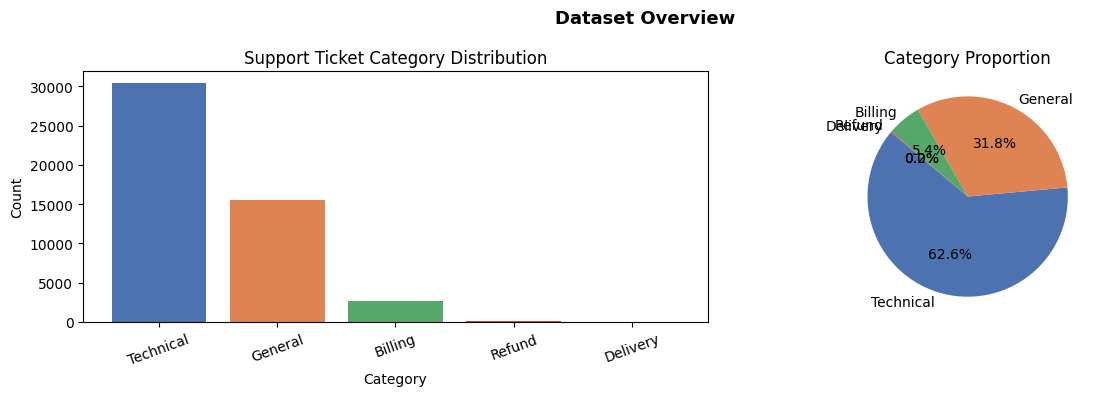

In [12]:
# visualizing the class distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

label_counts = df_clean['label'].value_counts()
axes[0].bar(label_counts.index, label_counts.values, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
axes[0].set_title('Support Ticket Category Distribution')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452', '#55A868', '#C44E52'], startangle=140)
axes[1].set_title('Category Proportion')

plt.suptitle('Dataset Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Text length stats:
count    48585.000000
mean        54.957518
std         31.739040
min          1.000000
25%         29.000000
50%         53.000000
75%         79.000000
max        281.000000
Name: text_len, dtype: float64


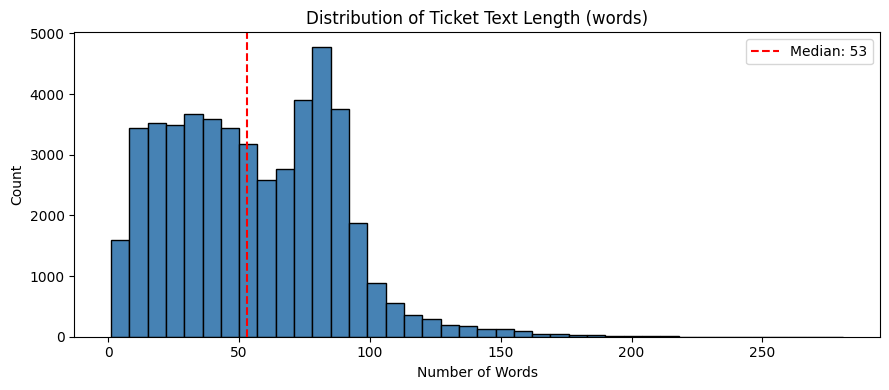

In [13]:
# checking ticket text length distribution
df_clean['text_len'] = df_clean['text'].apply(lambda x: len(x.split()))
print("Text length stats:")
print(df_clean['text_len'].describe())

plt.figure(figsize=(9, 4))
plt.hist(df_clean['text_len'], bins=40, color='steelblue', edgecolor='black')
plt.axvline(df_clean['text_len'].median(), color='red', linestyle='--', label=f'Median: {df_clean["text_len"].median():.0f}')
plt.title('Distribution of Ticket Text Length (words)')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# splitting into train and test sets - 80/20 split, stratified to maintain class balance
X = df_clean['text'].tolist()
y = df_clean['label_id'].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 38868
Test samples: 9717


In [15]:
# loading the pre-trained DistilBERT tokenizer
# using distilbert as it's lighter and faster than full BERT while keeping good accuracy
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded")

# testing tokenizer on a sample
sample = "Payment failed twice and I still got charged"
tokens = tokenizer(sample, return_tensors='pt')
print("\nSample tokenization:")
print("Input IDs:", tokens['input_ids'])
print("Decoded:", tokenizer.decode(tokens['input_ids'][0]))

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded

Sample tokenization:
Input IDs: tensor([[ 101, 7909, 3478, 3807, 1998, 1045, 2145, 2288, 5338,  102]])
Decoded: [CLS] payment failed twice and i still got charged [SEP]


In [16]:
# creating a custom PyTorch Dataset class to handle tokenization and batching

class TicketDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# creating dataset and dataloader objects
BATCH_SIZE = 16

train_dataset = TicketDataset(X_train, y_train, tokenizer, MAX_LEN)
test_dataset = TicketDataset(X_test, y_test, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 2430
Test batches: 608


In [17]:
# loading the pre-trained DistilBERT model with a classification head on top
# the model will have num_labels output neurons for our categories

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)
model = model.to(device)

print("Model loaded")
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded
Total parameters: 66,957,317
Trainable parameters: 66,957,317


In [20]:
# setting up the optimizer and learning rate scheduler
# using AdamW as recommended for transformer fine-tuning

EPOCHS = 1
LEARNING_RATE = 2e-5

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

num_training_steps = EPOCHS * len(train_loader)
num_warmup_steps = num_training_steps // 10

lr_scheduler = get_scheduler(
    name='linear',
    optimizer=optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

print(f"Training for {EPOCHS} epochs")
print(f"Total training steps: {num_training_steps}")
print(f"Warmup steps: {num_warmup_steps}")

Training for 1 epochs
Total training steps: 2430
Warmup steps: 243


In [21]:
# training the model - fine-tuning DistilBERT on our ticket classification task

def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, batch in enumerate(loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        original_labels = batch['labels'].to(device) # Store original labels

        # Convert labels to float if num_labels is 1 (regression task) for loss calculation
        processed_labels = original_labels.float() if num_labels == 1 else original_labels

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=processed_labels)

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        # For accuracy calculation, use original_labels which are Long
        # argmax on (batch_size, 1) logits will always return 0, which matches original_labels (all 0)
        preds = torch.argmax(logits, dim=1) # This will be 0 for all samples if num_labels=1
        correct += (preds == original_labels).sum().item() # Compare Long with Long
        total += original_labels.size(0)

        if (batch_idx + 1) % 10 == 0:
            print(f"  Batch {batch_idx+1}/{len(loader)} - Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy


def eval_epoch(model, loader, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            original_labels = batch['labels'].to(device) # Store original labels

            # Convert labels to float if num_labels is 1 (regression task) for loss calculation
            processed_labels = original_labels.float() if num_labels == 1 else original_labels

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=processed_labels)
            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1) # This will be 0 for all samples if num_labels=1
            correct += (preds == original_labels).sum().item() # Compare Long with Long
            total += original_labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(original_labels.cpu().numpy()) # Extend with original labels

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy, all_preds, all_labels


# running the training loop
train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, lr_scheduler, device)
    vl_loss, vl_acc, _, _ = eval_epoch(model, test_loader, device)

    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    val_losses.append(vl_loss)
    val_accs.append(vl_acc)

    print(f"Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.4f}")
    print(f"Val Loss:   {vl_loss:.4f} | Val Acc:   {vl_acc:.4f}")


Epoch 1/1
----------------------------------------
  Batch 10/2430 - Loss: 0.1773
  Batch 20/2430 - Loss: 0.0640
  Batch 30/2430 - Loss: 0.4567
  Batch 40/2430 - Loss: 0.6004
  Batch 50/2430 - Loss: 0.1270
  Batch 60/2430 - Loss: 0.1515
  Batch 70/2430 - Loss: 0.3445
  Batch 80/2430 - Loss: 0.4256
  Batch 90/2430 - Loss: 0.2274
  Batch 100/2430 - Loss: 0.2486
  Batch 110/2430 - Loss: 0.2644
  Batch 120/2430 - Loss: 0.2243
  Batch 130/2430 - Loss: 0.2739
  Batch 140/2430 - Loss: 0.2077
  Batch 150/2430 - Loss: 0.5510
  Batch 160/2430 - Loss: 0.3215
  Batch 170/2430 - Loss: 0.4836
  Batch 180/2430 - Loss: 0.3146
  Batch 190/2430 - Loss: 0.1387
  Batch 200/2430 - Loss: 0.8651
  Batch 210/2430 - Loss: 0.3221
  Batch 220/2430 - Loss: 0.0943
  Batch 230/2430 - Loss: 0.3404
  Batch 240/2430 - Loss: 0.3280
  Batch 250/2430 - Loss: 0.3465
  Batch 260/2430 - Loss: 0.3535
  Batch 270/2430 - Loss: 0.2087
  Batch 280/2430 - Loss: 0.2803
  Batch 290/2430 - Loss: 0.4849
  Batch 300/2430 - Loss: 0.52

In [23]:
# final evaluation on the test set
_, test_acc, test_preds, test_labels = eval_epoch(model, test_loader, device)

print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final F1 Score (weighted): {f1_score(test_labels, test_preds, average='weighted'):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(
    test_labels,
    test_preds,
    target_names=label_encoder.classes_
))

Final Test Accuracy: 0.9140
Final F1 Score (weighted): 0.9132

Detailed Classification Report:
              precision    recall  f1-score   support

     Billing       0.94      0.96      0.95       525
    Delivery       0.00      0.00      0.00         4
     General       0.89      0.84      0.87      3094
      Refund       0.82      0.60      0.69        15
   Technical       0.92      0.95      0.93      6079

    accuracy                           0.91      9717
   macro avg       0.71      0.67      0.69      9717
weighted avg       0.91      0.91      0.91      9717



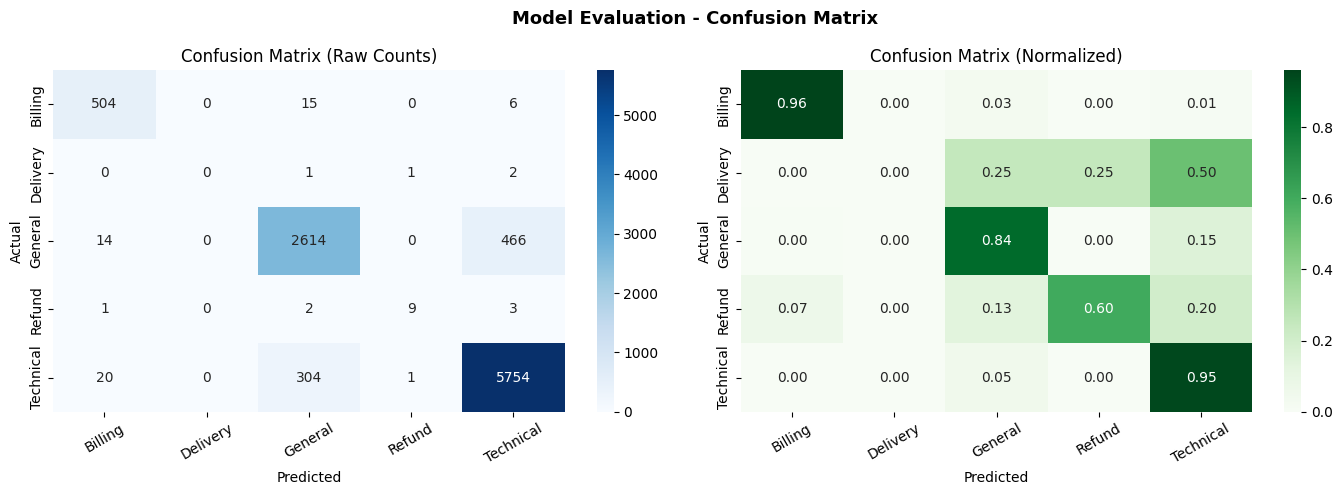

In [24]:
# confusion matrix to see where the model is getting confused
cm = confusion_matrix(test_labels, test_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
axes[0].set_title('Confusion Matrix (Raw Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Model Evaluation - Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

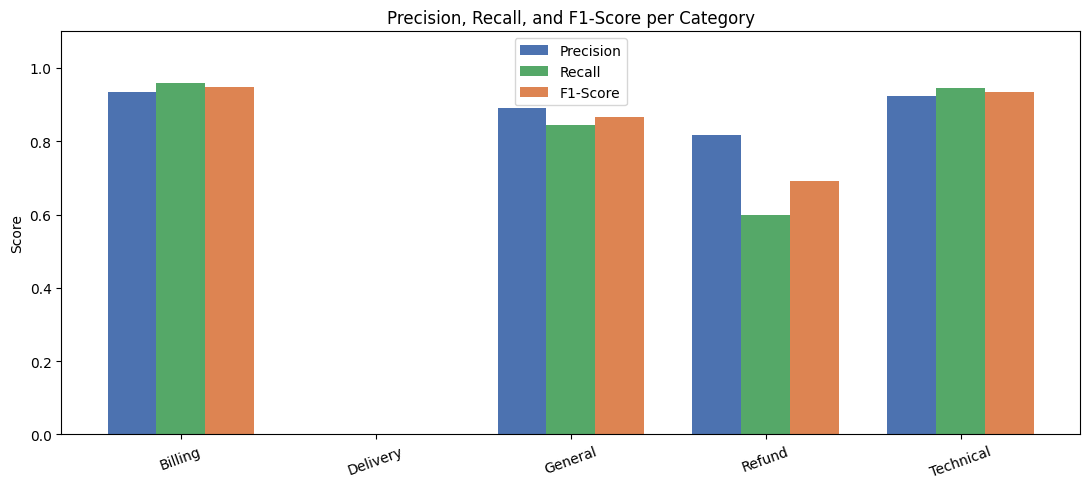

In [25]:
# per-class F1 score bar chart
report = classification_report(
    test_labels, test_preds,
    target_names=label_encoder.classes_,
    output_dict=True
)

class_names = label_encoder.classes_
f1_scores = [report[cls]['f1-score'] for cls in class_names]
precisions = [report[cls]['precision'] for cls in class_names]
recalls = [report[cls]['recall'] for cls in class_names]

x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(11, 5))
plt.bar(x - width, precisions, width, label='Precision', color='#4C72B0')
plt.bar(x, recalls, width, label='Recall', color='#55A868')
plt.bar(x + width, f1_scores, width, label='F1-Score', color='#DD8452')
plt.xticks(x, class_names, rotation=20)
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Precision, Recall, and F1-Score per Category')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# building the end-to-end inference pipeline using huggingface pipeline API

classifier_pipeline = pipeline(
    task='text-classification',
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    return_all_scores=True
)

print("Inference pipeline ready")

Inference pipeline ready


In [28]:
# testing the pipeline on sample tickets similar to the assignment examples
sample_tickets = [
    "Payment failed twice and I was charged both times",
    "Cannot login to my account, keeps saying invalid password",
    "My package arrived damaged and the screen is cracked",
    "Refund pending for 2 weeks, please help",
    "Delivery delayed by 10 days, no updates from courier",
    "The app crashes every time I try to open it",
    "I was billed twice for the same subscription",
    "Product quality is very poor, want to return it"
]

print("Ticket Classification Results")
print("=" * 60)

for ticket in sample_tickets:
    # classifier_pipeline(ticket) typically returns List[List[Dict]] when return_all_scores=True.
    # However, based on the error, it appears to sometimes return List[Dict] for a single input.
    # We need to ensure `all_scores` is always a List[Dict].
    pipeline_output_for_single_ticket = classifier_pipeline(ticket)

    # The first element [0] will be the list of scores (e.g., [d1, d2, ...]) or a single dict (d1).
    all_scores = pipeline_output_for_single_ticket[0]

    # If all_scores is a single dictionary, wrap it in a list to make it iterable for max/sorted.
    if isinstance(all_scores, dict):
        all_scores = [all_scores]

    # getting the top predicted label
    top_pred = max(all_scores, key=lambda x: x['score'])

    print(f"\nTicket : {ticket}")
    print(f"Predicted: {top_pred['label']} (confidence: {top_pred['score']:.4f})")
    print("All scores:")
    for item in sorted(all_scores, key=lambda x: x['score'], reverse=True):
        bar = '█' * int(item['score'] * 20)
        print(f"  {item['label']:12s}: {bar} {item['score']:.4f}")

Ticket Classification Results

Ticket : Payment failed twice and I was charged both times
Predicted: Billing (confidence: 0.9792)
All scores:
  Billing     : ███████████████████ 0.9792

Ticket : Cannot login to my account, keeps saying invalid password
Predicted: Technical (confidence: 0.9660)
All scores:
  Technical   : ███████████████████ 0.9660

Ticket : My package arrived damaged and the screen is cracked
Predicted: Technical (confidence: 0.9066)
All scores:
  Technical   : ██████████████████ 0.9066

Ticket : Refund pending for 2 weeks, please help
Predicted: Billing (confidence: 0.9672)
All scores:
  Billing     : ███████████████████ 0.9672

Ticket : Delivery delayed by 10 days, no updates from courier
Predicted: Technical (confidence: 0.4807)
All scores:
  Technical   : █████████ 0.4807

Ticket : The app crashes every time I try to open it
Predicted: Technical (confidence: 0.7083)
All scores:
  Technical   : ██████████████ 0.7083

Ticket : I was billed twice for the same subscrip